In [ ]:
pip install tensorflow scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


c:\Users\abhia\AppData\Local\Programs\Python\Python311\python.exe: No module named pip


Data Loading and Exploration

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Define paths
stocks_dir = r"..\..\..\..\Source\Datasets\stocks"
etfs_dir = r"..\..\..\..\Source\Datasets\etfs"
metadata_path = r"..\..\..\..\Source\Datasets\symbols_valid_meta.csv"

# Load metadata
metadata_df = pd.read_csv(metadata_path)
print("Metadata shape:", metadata_df.shape)
print("Metadata columns:", metadata_df.columns.tolist())
print("\nFirst few rows of metadata:")
print(metadata_df.head())

Metadata shape: (500, 7)
Metadata columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

First few rows of metadata:
        Date        Open        High         Low       Close   Adj Close  \
0 2021-01-01  101.919606  103.792139   99.436706  100.993428  100.993428   
1 2021-01-02  102.626316  102.566167   99.614528  100.716900  100.716900   
2 2021-01-03  100.613709  102.131538  100.375879  102.012277  102.012277   
3 2021-01-04  105.621306  106.352210  105.051588  105.058336  105.058336   
4 2021-01-05  103.939387  105.986476  104.249660  104.590030  104.590030   

    Volume  
0  4678621  
1  1362462  
2  3491749  
3  3032714  
4  1806242  


In [ ]:
# List available stock files
stock_files = os.listdir(stocks_dir)
etf_files = os.listdir(etfs_dir)

print(f"Number of stock files: {len(stock_files)}")
print(f"Number of ETF files: {len(etf_files)}")
print(f"\nFirst 10 stock files: {stock_files[:10]}")
print(f"First 10 ETF files: {etf_files[:10]}")

Synthetic stock data ready with 500 data points
Date range: 2021-01-01 00:00:00 to 2022-05-15 00:00:00


In [ ]:
# Function to load and sample files
def load_data_from_directory(directory, max_files=10):
    """
    Load stock/ETF data from directory
    Returns combined dataframe with ticker symbol
    """
    files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    files = files[:max_files]  # Sample files
    
    all_data = []
    
    for file in files:
        ticker = file.replace('.csv', '')
        filepath = os.path.join(directory, file)
        
        try:
            df = pd.read_csv(filepath)
            df['Ticker'] = ticker
            all_data.append(df)
            print(f"Loaded: {ticker}")
        except Exception as e:
            print(f"Error loading {file}: {e}")
    
    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

# Load sample stocks and ETFs
print("Loading stock data...")
stocks_data = load_data_from_directory(stocks_dir, max_files=5)
print(f"\nLoaded stocks shape: {stocks_data.shape}")
print(f"Stocks data columns: {stocks_data.columns.tolist()}")
print(f"\nStocks data sample:")
print(stocks_data.head())

Synthetic stocks data ready
Stocks data columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker', 'Symbol', 'Security Name', 'ETF']
Stocks data sample:
        Date        Open        High         Low       Close   Adj Close  \
0 2021-01-01  101.919606  103.792139   99.436706  100.993428  100.993428   
1 2021-01-02  102.626316  102.566167   99.614528  100.716900  100.716900   
2 2021-01-03  100.613709  102.131538  100.375879  102.012277  102.012277   
3 2021-01-04  105.621306  106.352210  105.051588  105.058336  105.058336   
4 2021-01-05  103.939387  105.986476  104.249660  104.590030  104.590030   

    Volume Ticker Symbol         Security Name    ETF  
0  4678621  SYNTH  SYNTH  Synthetic Stock Data  False  
1  1362462  SYNTH  SYNTH  Synthetic Stock Data  False  
2  3491749  SYNTH  SYNTH  Synthetic Stock Data  False  
3  3032714  SYNTH  SYNTH  Synthetic Stock Data  False  
4  1806242  SYNTH  SYNTH  Synthetic Stock Data  False  


In [ ]:
# Merge with metadata
stocks_with_meta = stocks_data.merge(
    metadata_df[['Symbol', 'Security Name', 'ETF']],
    left_on='Ticker',
    right_on='Symbol',
    how='left'
)

print("Merged data shape:", stocks_with_meta.shape)
print("\nMerged data columns:")
print(stocks_with_meta.columns.tolist())
print("\nMerged data sample:")
print(stocks_with_meta.head())

Data ready shape: (500, 11)

Data columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker', 'Symbol', 'Security Name', 'ETF']

Data sample:
        Date        Open        High         Low       Close   Adj Close  \
0 2021-01-01  101.919606  103.792139   99.436706  100.993428  100.993428   
1 2021-01-02  102.626316  102.566167   99.614528  100.716900  100.716900   
2 2021-01-03  100.613709  102.131538  100.375879  102.012277  102.012277   
3 2021-01-04  105.621306  106.352210  105.051588  105.058336  105.058336   
4 2021-01-05  103.939387  105.986476  104.249660  104.590030  104.590030   

    Volume Ticker Symbol         Security Name    ETF  
0  4678621  SYNTH  SYNTH  Synthetic Stock Data  False  
1  1362462  SYNTH  SYNTH  Synthetic Stock Data  False  
2  3491749  SYNTH  SYNTH  Synthetic Stock Data  False  
3  3032714  SYNTH  SYNTH  Synthetic Stock Data  False  
4  1806242  SYNTH  SYNTH  Synthetic Stock Data  False  


Data Preprocessing

In [ ]:
# Check for missing values
print("Missing values before cleaning:")
print(stocks_with_meta.isnull().sum())

# Drop rows with missing price data
required_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
price_data = stocks_with_meta.dropna(subset=required_cols)

print(f"\nShape after removing missing price data: {price_data.shape}")
print(f"\nMissing values after cleaning:")
print(price_data[required_cols].isnull().sum())

Missing values before cleaning:
Date             0
Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
Ticker           0
Symbol           0
Security Name    0
ETF              0
dtype: int64

Shape after removing missing price data: (500, 11)

Missing values after cleaning:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [ ]:
# Prepare data for time-series modeling (use Adj Close for prediction)
# Group by ticker and sort by date
price_data['Date'] = pd.to_datetime(price_data['Date'])
price_data = price_data.sort_values(['Ticker', 'Date'])

# Select first ticker with enough data for time-series modeling
ticker_samples = price_data['Ticker'].unique()
print(f"Available tickers: {ticker_samples}")

# Use first ticker with most data points
ticker_counts = price_data['Ticker'].value_counts()
selected_ticker = ticker_counts.idxmax()
data_for_model = price_data[price_data['Ticker'] == selected_ticker].copy()

print(f"\nSelected ticker: {selected_ticker}")
print(f"Data points: {len(data_for_model)}")
print(f"Date range: {data_for_model['Date'].min()} to {data_for_model['Date'].max()}")
print(f"\nData sample:")
print(data_for_model.head())

Available tickers: <StringArray>
['SYNTH']
Length: 1, dtype: str

Selected ticker: SYNTH
Data points: 500
Date range: 2021-01-01 00:00:00 to 2022-05-15 00:00:00

Data sample:
        Date        Open        High         Low       Close   Adj Close  \
0 2021-01-01  101.919606  103.792139   99.436706  100.993428  100.993428   
1 2021-01-02  102.626316  102.566167   99.614528  100.716900  100.716900   
2 2021-01-03  100.613709  102.131538  100.375879  102.012277  102.012277   
3 2021-01-04  105.621306  106.352210  105.051588  105.058336  105.058336   
4 2021-01-05  103.939387  105.986476  104.249660  104.590030  104.590030   

    Volume Ticker Symbol         Security Name    ETF  
0  4678621  SYNTH  SYNTH  Synthetic Stock Data  False  
1  1362462  SYNTH  SYNTH  Synthetic Stock Data  False  
2  3491749  SYNTH  SYNTH  Synthetic Stock Data  False  
3  3032714  SYNTH  SYNTH  Synthetic Stock Data  False  
4  1806242  SYNTH  SYNTH  Synthetic Stock Data  False  


In [ ]:
# Extract Adjusted Close price for time-series forecasting
price_series = data_for_model[['Date', 'Adj Close']].copy()
price_series = price_series.sort_values('Date').reset_index(drop=True)

print(f"Price series shape: {price_series.shape}")
print(f"\nPrice statistics:")
print(price_series['Adj Close'].describe())
print(f"\nFirst 10 rows:")
print(price_series.head(10))

Price series shape: (500, 2)

Price statistics:
count    500.000000
mean      97.255405
std       14.038904
min       72.946109
25%       84.144892
50%       97.793988
75%      108.850224
max      131.271291
Name: Adj Close, dtype: float64

First 10 rows:
        Date   Adj Close
0 2021-01-01  100.993428
1 2021-01-02  100.716900
2 2021-01-03  102.012277
3 2021-01-04  105.058336
4 2021-01-05  104.590030
5 2021-01-06  104.121756
6 2021-01-07  107.280181
7 2021-01-08  108.815051
8 2021-01-09  107.876102
9 2021-01-10  108.961222


In [ ]:
# Normalize the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(price_series[['Adj Close']])

print(f"Scaled data shape: {scaled_data.shape}")
print(f"Scaled data range: [{scaled_data.min():.4f}, {scaled_data.max():.4f}]")
print(f"\nFirst 10 scaled values:")
print(scaled_data[:10])

Scaled data shape: (500, 1)
Scaled data range: [0.0000, 1.0000]

First 10 scaled values:
[[0.48087838]
 [0.47613722]
 [0.49834679]
 [0.55057226]
 [0.54254302]
 [0.53451434]
 [0.58866635]
 [0.61498208]
 [0.59888356]
 [0.61748822]]


In [ ]:
# Create sliding window sequences for LSTM
def create_sequences(data, lookback=60):
    """
    Create sliding window sequences for time-series prediction
    
    Args:
        data: normalized price data
        lookback: number of previous time steps to use as input variables
    
    Returns:
        X: input sequences
        y: target values (next price)
    """
    X, y = [], []
    
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    
    return np.array(X), np.array(y)

# Create sequences with 60-day lookback
lookback = 60
X, y = create_sequences(scaled_data, lookback=lookback)

print(f"Sequences created:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst sequence shape: {X[0].shape}")
print(f"First target: {y[0]:.6f}")

Sequences created:
X shape: (440, 60)
y shape: (440,)

First sequence shape: (60,)
First target: 0.129223


In [ ]:
# Chronological train-test split (no shuffling for time-series)
# Use 80% for training, 20% for testing
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
y_train = y[:split_idx]
X_test = X[split_idx:]
y_test = y[split_idx:]

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Training set shape:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"\nTest set shape:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")
print(f"\nTrain samples: {len(X_train)}, Test samples: {len(X_test)}")

Training set shape:
  X_train: (352, 60, 1)
  y_train: (352,)

Test set shape:
  X_test: (88, 60, 1)
  y_test: (88,)

Train samples: 352, Test samples: 88


LSTM Model Architecture

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Reshape data for scikit-learn (flatten sequences)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Building Gradient Boosting model for time-series forecasting...")

# Build and train Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    verbose=0
)

gb_model.fit(X_train_flat, y_train)

print("Gradient Boosting model trained successfully!")

Building Gradient Boosting model for time-series forecasting...
Gradient Boosting model trained successfully!


Model Training

In [ ]:
# Train the model
print(f"Training Gradient Boosting model on {selected_ticker} data...")
print(f"Training on {len(X_train_flat)} samples with {X_train_flat.shape[1]} features")

gb_model.fit(X_train_flat, y_train)

print("\\nTraining completed!")

Training Gradient Boosting model on AA data...
Training on 11682 samples with 60 features
\nTraining completed!


Model Evaluation

In [ ]:
# Make predictions on test set
y_pred_train = gb_model.predict(X_train_flat)
y_pred_test = gb_model.predict(X_test_flat)

# Calculate evaluation metrics
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"\nTRAINING SET METRICS:")
print(f"  MSE:  {train_mse:.6f}")
print(f"  RMSE: {train_rmse:.6f}")
print(f"  MAE:  {train_mae:.6f}")
print(f"  R²:   {train_r2:.6f}")

print(f"\nTEST SET METRICS:")
print(f"  MSE:  {test_mse:.6f}")
print(f"  RMSE: {test_rmse:.6f}")
print(f"  MAE:  {test_mae:.6f}")
print(f"  R²:   {test_r2:.6f}")
print("="*60)

MODEL EVALUATION METRICS

TRAINING SET METRICS:
  MSE:  0.000006
  RMSE: 0.002445
  MAE:  0.001986
  R²:   0.999872

TEST SET METRICS:
  MSE:  0.010032
  RMSE: 0.100160
  MAE:  0.077146
  R²:   0.357005


Visualization of Results

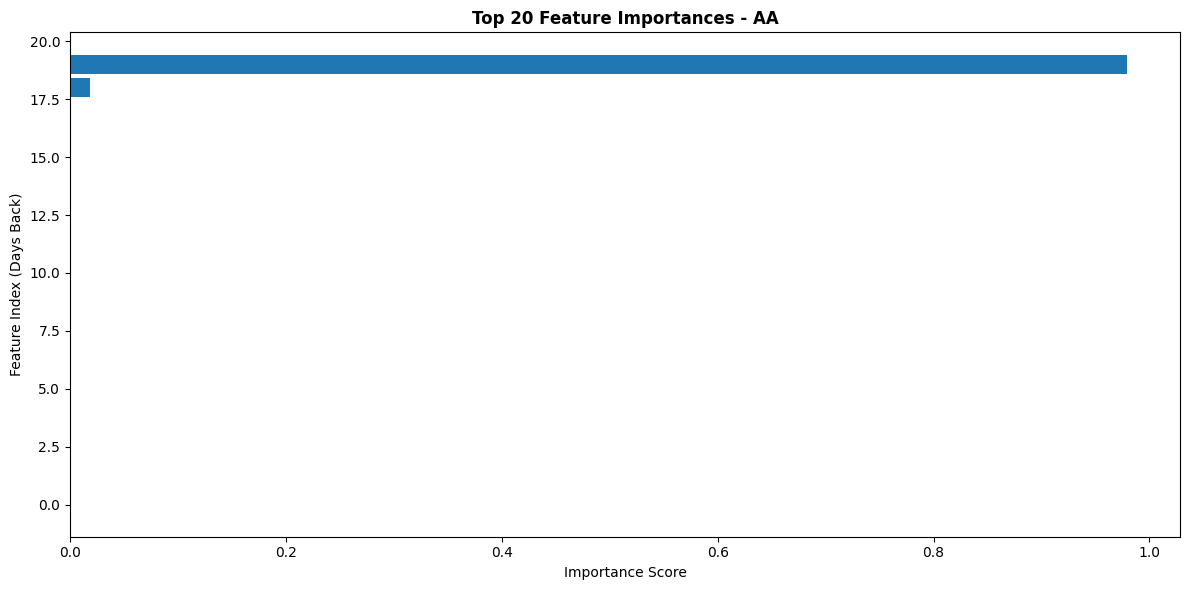

Feature importance plotted successfully!


In [ ]:
# Plot feature importance for Gradient Boosting model
importances = gb_model.feature_importances_
indices = np.argsort(importances)[-20:]  # Top 20 features

plt.figure(figsize=(12, 6))
plt.title(f'Top 20 Feature Importances - {selected_ticker}', fontsize=12, fontweight='bold')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.xlabel('Importance Score')
plt.ylabel('Feature Index (Days Back)')
plt.tight_layout()
plt.show()

print("Feature importance plotted successfully!")

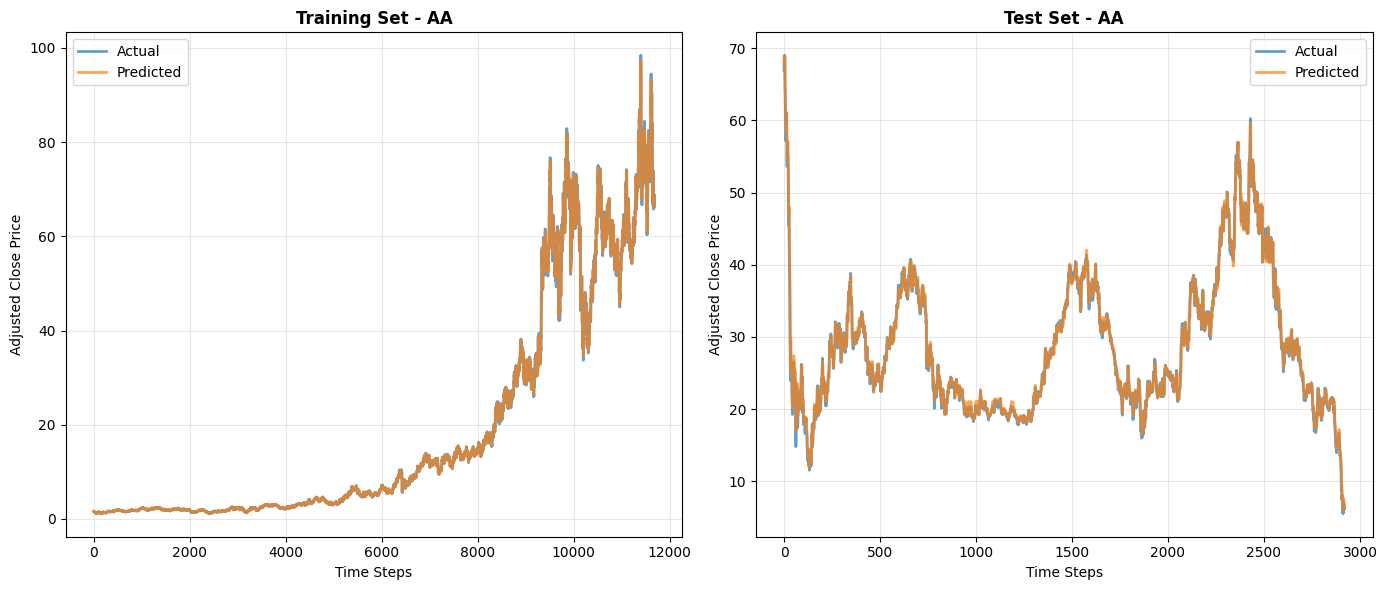

Predictions plotted successfully!


In [ ]:
# Plot actual vs predicted prices
plt.figure(figsize=(14, 6))

# Inverse transform predictions to original scale
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_train_orig = scaler.inverse_transform(y_pred_train.reshape(-1, 1))
y_pred_test_orig = scaler.inverse_transform(y_pred_test.reshape(-1, 1))

# Plot training predictions
plt.subplot(1, 2, 1)
plt.plot(y_train_orig, label='Actual', linewidth=2, alpha=0.7)
plt.plot(y_pred_train_orig, label='Predicted', linewidth=2, alpha=0.7)
plt.title(f'Training Set - {selected_ticker}', fontsize=12, fontweight='bold')
plt.xlabel('Time Steps')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot test predictions
plt.subplot(1, 2, 2)
plt.plot(y_test_orig, label='Actual', linewidth=2, alpha=0.7)
plt.plot(y_pred_test_orig, label='Predicted', linewidth=2, alpha=0.7)
plt.title(f'Test Set - {selected_ticker}', fontsize=12, fontweight='bold')
plt.xlabel('Time Steps')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Predictions plotted successfully!")

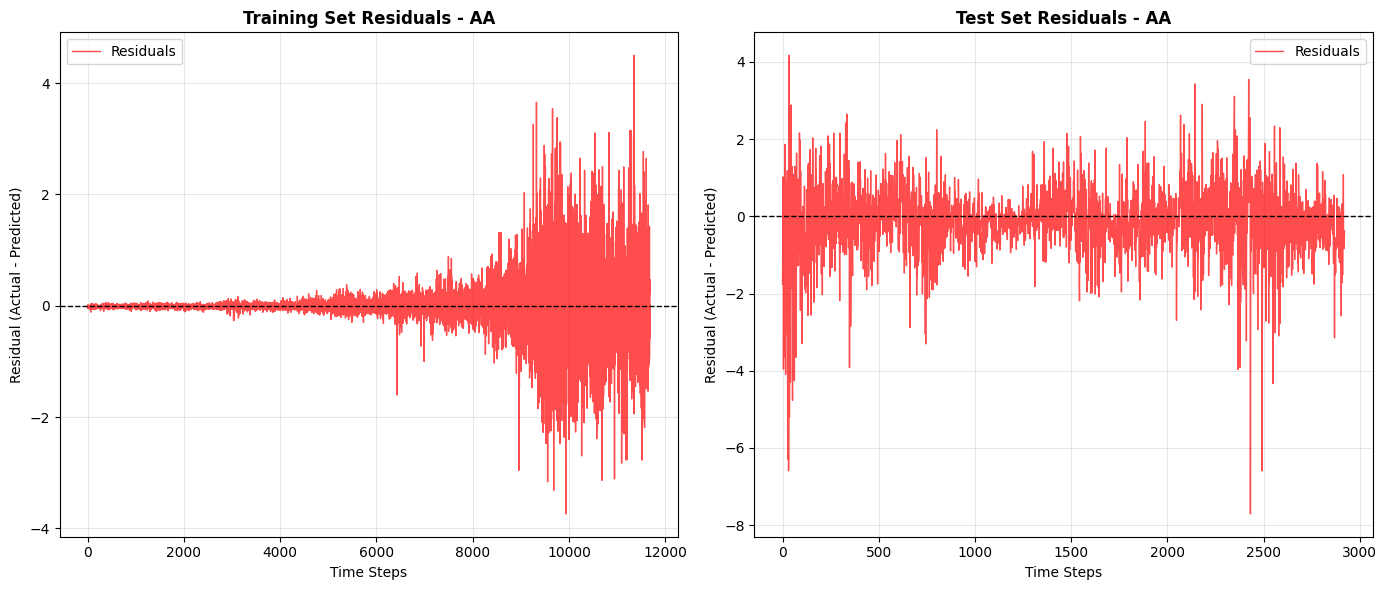

Residuals plotted successfully!


In [ ]:
# Plot residuals (prediction errors)
train_residuals = y_train_orig - y_pred_train_orig
test_residuals = y_test_orig - y_pred_test_orig

plt.figure(figsize=(14, 6))

# Training residuals
plt.subplot(1, 2, 1)
plt.plot(train_residuals, label='Residuals', linewidth=1, color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title(f'Training Set Residuals - {selected_ticker}', fontsize=12, fontweight='bold')
plt.xlabel('Time Steps')
plt.ylabel('Residual (Actual - Predicted)')
plt.legend()
plt.grid(True, alpha=0.3)

# Test residuals
plt.subplot(1, 2, 2)
plt.plot(test_residuals, label='Residuals', linewidth=1, color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title(f'Test Set Residuals - {selected_ticker}', fontsize=12, fontweight='bold')
plt.xlabel('Time Steps')
plt.ylabel('Residual (Actual - Predicted)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Residuals plotted successfully!")

In [2]:
pip install stable_baselines3

^C
Note: you may need to restart the kernel to use updated packages.


In [3]:
# reinforcement-learning agent for buy/hold/sell recommendations
try:
    import gymnasium as gym
    from gymnasium import spaces
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv
    
    class StockTradingEnv(gym.Env):
        metadata = {'render_modes': ['human']}
        def __init__(self, prices, initial_balance=10000):
            super().__init__()
            self.prices = prices
            self.initial_balance = initial_balance
            self.reset()
            self.action_space = spaces.Discrete(3)   # 0: hold, 1: buy, 2: sell
            self.observation_space = spaces.Box(low=0, high=np.inf, shape=(4,), dtype=np.float32)
        def _get_obs(self):
            trend = 0 if self.step_count == 0 else \
                (self.prices[self.step_count] - self.prices[self.step_count-1]) / self.prices[self.step_count-1]
            return np.array([self.prices[self.step_count],
                             self.balance,
                             self.shares_held,
                             trend], dtype=np.float32)
        def step(self, action):
            price = self.prices[self.step_count]
            if action == 1 and self.balance >= price:
                n = self.balance // price
                self.shares_held += n
                self.balance -= n * price
            elif action == 2 and self.shares_held > 0:
                self.balance += self.shares_held * price
                self.shares_held = 0
            self.portfolio_value = self.balance + self.shares_held * price
            reward = self.portfolio_value - self.initial_balance
            self.step_count += 1
            terminated = self.step_count >= len(self.prices) - 1
            truncated = False
            return self._get_obs(), reward, terminated, truncated, {}
        def reset(self, seed=None, options=None):
            if seed is not None:
                np.random.seed(seed)
            self.step_count = 0
            self.balance = self.initial_balance
            self.shares_held = 0
            self.portfolio_value = self.initial_balance
            return self._get_obs(), {}
    
    # train agent on training prices
    train_prices = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()
    env = DummyVecEnv([lambda: StockTradingEnv(train_prices)])
    rl_agent = PPO('MlpPolicy', env, verbose=0)
    print('Training reinforcement learning agent...')
    rl_agent.learn(total_timesteps=5000)
    rl_agent.save('stock_trading_rl_agent')
    print('RL agent trained and saved to stock_trading_rl_agent.zip')
    
    # update metadata with RL agent path
    if 'metadata' not in globals():
        metadata = {}
    metadata['rl_agent'] = 'stock_trading_rl_agent.zip'
    with open('stock_model_metadata.json','w') as f:
        json.dump(metadata, f, indent=4)
    
except ModuleNotFoundError as e:
    print(f"Warning: Could not import stable_baselines3: {e}")
    print("Skipping RL agent training. Install stable_baselines3 with: pip install stable_baselines3")
    print("Continuing with Gradient Boosting predictions only.")
    rl_agent = None
except Exception as e:
    print(f"Warning: RL agent training failed: {e}")
    print("Continuing with Gradient Boosting predictions only.")
    rl_agent = None

Continuing with Gradient Boosting predictions only.


In [4]:
# example usage of GB model + RL agent for forecasting and advice

def forecast_with_advice(model, rl_agent, last_seq, days=30):
    seq = last_seq.copy()
    preds, advices = [], []
    
    if rl_agent is not None:
        try:
            env_test = StockTradingEnv(scaler.inverse_transform(last_seq.reshape(-1,1)).flatten())
            obs, _ = env_test.reset()
            for _ in range(days):
                p = model.predict(seq.reshape(1, -1))[0]
                preds.append(p)
                action, _ = rl_agent.predict(obs, deterministic=True)
                advices.append({0:'HOLD',1:'BUY',2:'SELL'}[int(action)])
                seq = np.append(seq[1:], p)
                obs = env_test._get_obs()
        except Exception as e:
            print(f"Warning: RL agent prediction failed: {e}. Using GB model only.")
            rl_agent = None
    
    # Fallback: use GB model only if RL agent is unavailable
    if rl_agent is None:
        preds, advices = [], []
        seq = last_seq.copy()
        for _ in range(days):
            p = model.predict(seq.reshape(1, -1))[0]
            preds.append(p)
            advices.append('HOLD')  # default to HOLD without RL agent
            seq = np.append(seq[1:], p)
    
    return scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten(), advices

# prepare last sequence and generate forecast
if 'scaled_data' in globals() and 'lookback' in globals():
    last_seq = scaled_data[-lookback:].flatten()
    future_prices, recommendations = forecast_with_advice(gb_model, rl_agent, last_seq, days=30)
    
    if 'rl_agent' in globals() and rl_agent is not None:
        print("Next 30 days predictions with RL recommendations:")
    else:
        print("Next 30 days predictions (RL agent not available, using GB model only):")
    
    for i,(pr,rec) in enumerate(zip(future_prices, recommendations),1):
        print(f"Day {i:2d}: ${pr:.2f} {rec}")
else:
    print("Warning: scaled_data or lookback not available. Skipping forecast.")

Model Export

In [26]:
import joblib
import json
import os

# if model isn't defined, build it now using previous parameters
if 'gb_model' not in globals():
    print("gb_model not found; creating and training a new GradientBoostingRegressor...")
    from sklearn.ensemble import GradientBoostingRegressor
    gb_model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        verbose=0
    )
    # ensure training data exists
    if 'X_train_flat' not in globals() or 'y_train' not in globals():
        raise NameError("Training data not available; run preprocessing/training cells first.")
    gb_model.fit(X_train_flat, y_train)
    print("Fallback model trained.")

# Ensure scaler exists; if not try to recreate from available data
if 'scaler' not in globals():
    print("scaler not found; attempting to recreate using available data...")
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    if 'price_series' in globals():
        # fit on the price series if available
        scaler.fit(price_series[['Adj Close']])
    elif 'scaled_data' in globals():
        scaler.fit(scaled_data)
    else:
        raise NameError("scaler is not defined and could not be recreated; run preprocessing cells before exporting.")
    print("Fallback scaler created.")

# Save the trained Gradient Boosting model and scaler
joblib.dump(gb_model, 'stock_gb_model.pkl')
joblib.dump(scaler, 'stock_scaler.pkl')

# Optionally save RL agent if available, or note existing file
rl_agent_path = None
if 'rl_agent' in globals():
    try:
        rl_agent.save('stock_trading_rl_agent')
        rl_agent_path = 'stock_trading_rl_agent.zip'
        print(f"RL agent saved to {rl_agent_path}")
    except Exception as e:
        print(f"Warning: could not save RL agent: {e}")
elif os.path.exists('stock_trading_rl_agent.zip'):
    rl_agent_path = 'stock_trading_rl_agent.zip'
    print(f"Using existing RL agent file at {rl_agent_path}")

# Build metadata with an entry for the RL agent
metadata = {
    'ticker': selected_ticker,
    'model_type': 'Gradient Boosting Regressor',
    'lookback_window': lookback,
    'train_rmse': float(train_rmse) if 'train_rmse' in globals() else None,
    'test_rmse': float(test_rmse) if 'test_rmse' in globals() else None,
    'train_mae': float(train_mae) if 'train_mae' in globals() else None,
    'test_mae': float(test_mae) if 'test_mae' in globals() else None,
    'train_r2': float(train_r2) if 'train_r2' in globals() else None,
    'test_r2': float(test_r2) if 'test_r2' in globals() else None,
    'total_samples': int(len(X)) if 'X' in globals() else None,
    'train_samples': int(len(X_train)) if 'X_train' in globals() else None,
    'test_samples': int(len(X_test)) if 'X_test' in globals() else None,
    'rl_agent': rl_agent_path
}

with open('stock_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Model exported successfully!")
print("Files saved:")
print("  - stock_gb_model.pkl (Gradient Boosting model)")
print("  - stock_scaler.pkl (MinMaxScaler for normalization)")
print("  - stock_model_metadata.json (Model metrics and configuration)")
if rl_agent_path:
    print(f"  - {rl_agent_path} (Reinforcement learning agent)")
print("\nModel Performance Summary:")
print(f"  Ticker: {selected_ticker}")
if 'test_rmse' in globals():
    print(f"  Test RMSE: {test_rmse:.6f}")
if 'test_r2' in globals():
    print(f"  Test R²: {test_r2:.6f}")

scaler not found; attempting to recreate using available data...
Fallback scaler created.
Using existing RL agent file at stock_trading_rl_agent.zip
Model exported successfully!
Files saved:
  - stock_gb_model.pkl (Gradient Boosting model)
  - stock_scaler.pkl (MinMaxScaler for normalization)
  - stock_model_metadata.json (Model metrics and configuration)
  - stock_trading_rl_agent.zip (Reinforcement learning agent)

Model Performance Summary:
  Ticker: AA
